In [33]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from calibration import lifetime_to_temperature_201112
from scipy.optimize import curve_fit
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import sem

In [34]:
files_path = glob.glob('./continuous/20111*_relaxation_whole_lin22.6_70msec_100mW_5sec/whole_cells/*.csv')
files_path.sort()

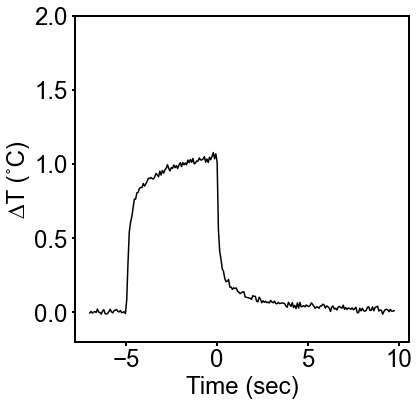

速い成分は0.106868sec
遅い成分は2.694872sec
割合は0.774309
時定数は2.384932


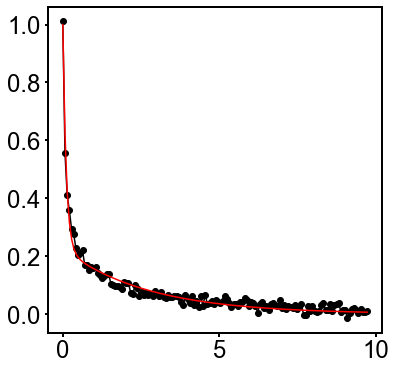

In [35]:
plt.figure(figsize = (6, 6))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
data_set_5sec = pd.DataFrame()

#データの平均化
average = np.zeros((1, 240))
for path in files_path:
    df = pd.read_csv(path, sep = '\t')
    relaxation_int = np.array(df.iloc[1:, 3], dtype = 'float32')
    relaxation = np.array(df.iloc[1:, 1], dtype = 'float32')
    diff = relaxation_int[:-1] - relaxation_int[1:]
    off_time = np.argmax(diff)
    extract = lifetime_to_temperature_201112(relaxation[off_time-100 : off_time+140])
    average += extract
    data_set_5sec = pd.concat([data_set_5sec, pd.DataFrame(extract)], axis = 1)
average_normal = average[0]/len(files_path)
average_normal = average_normal - np.mean(average_normal[:10])
time = [(i-100)*0.07 for i in range(len(average_normal))]
plt.tick_params(axis='both', direction = "out", labelsize = 24)
plt.plot(time, average_normal, color = 'Black')
plt.ylim(-0.2, 2.0)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('∆T (˚C)', fontsize = 24)
plt.show()


#温度緩和の時定数の計算
time = [(i)*0.07 for i in range(len(average_normal[100:]))]
def relaxation(time, ratio, t1, t2):
    return ratio*np.exp(-time/t1) + (1-ratio)*np.exp(-time/t2)
result = curve_fit(relaxation, time ,average_normal[100:])[0]
print('速い成分は%fsec' % result[1])
print('遅い成分は%fsec' % result[2])
print('割合は%f' % result[0])
time_constant = (result[0]*(result[1]**2) + (1-result[0])*(result[2]**2))/(result[0]*result[1] + (1-result[0])*(result[2]))
print('時定数は%f' % time_constant)

plt.figure(figsize = (6, 6))
plt.tick_params(axis='both', direction = "out", labelsize = 24)
plt.plot(time, average_normal[100:], color = 'Black', marker = 'o')
plt.plot(time, relaxation(np.ravel(time), result[0], result[1], result[2]), color = 'red')
plt.show()

In [36]:
files_path = glob.glob('./pulse/201117_relaxation_whole_lin22.6_70msec_200mW_100msec/whole_cells/*.csv')
files_path.sort()

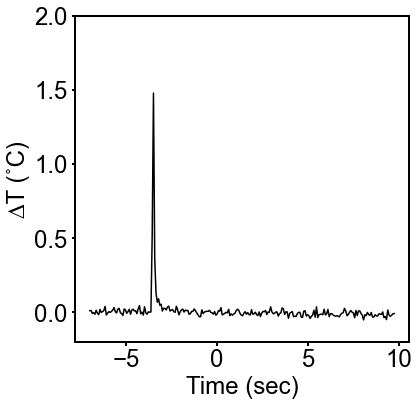

速い成分は0.057866sec
遅い成分は0.585111sec
割合は0.918714
時定数は0.306829


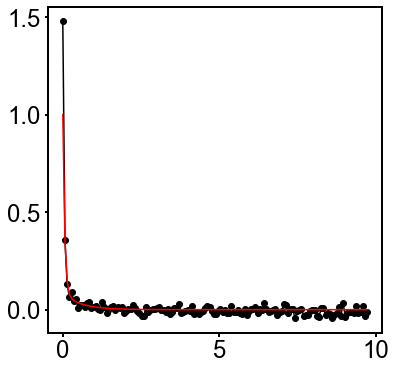

In [37]:
plt.figure(figsize = (6, 6))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
data_set_100msec = pd.DataFrame()

#データの平均化
average = np.zeros((1, 240))
for path in files_path:
    df = pd.read_csv(path, sep = '\t')
    relaxation_int = np.array(df.iloc[1:, 3], dtype = 'float32')
    relaxation = np.array(df.iloc[1:, 1], dtype = 'float32')
    diff = relaxation_int[:-1] - relaxation_int[1:]
    off_time = np.argmax(diff)
    extract = lifetime_to_temperature_201112(relaxation[off_time-50 : off_time+190])
    average += extract
    data_set_100msec = pd.concat([data_set_100msec, pd.DataFrame(extract)], axis = 1)
    
average_normal_100msec = average[0]/len(files_path)
average_normal_100msec = average_normal_100msec - np.mean(average_normal_100msec[:10])
time = [(i-100)*0.07 for i in range(len(average_normal_100msec))]
plt.tick_params(axis='both', direction = "out", labelsize = 24)
plt.plot(time, average_normal_100msec, color = 'Black')
plt.ylim(-0.2, 2)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('∆T (˚C)', fontsize = 24)
plt.show()


#温度緩和の時定数の計算
time = [(i)*0.07 for i in range(len(average_normal_100msec[50:190]))]
def relaxation(time, ratio, t1, t2):
    return ratio*np.exp(-time/t1) + (1-ratio)*np.exp(-time/t2)
result = curve_fit(relaxation, time ,average_normal_100msec[50:190])[0]
print('速い成分は%fsec' % result[1])
print('遅い成分は%fsec' % result[2])
print('割合は%f' % result[0])
time_constant = (result[0]*(result[1]**2) + (1-result[0])*(result[2]**2))/(result[0]*(result[1]) + (1-result[0])*(result[2]))
print('時定数は%f' % time_constant)

plt.figure(figsize = (6, 6))
plt.tick_params(axis='both', direction = "out", labelsize = 24)
plt.plot(time, average_normal_100msec[50:190], color = 'Black', marker = 'o')
plt.plot(time, relaxation(np.ravel(time), result[0], result[1], result[2]), color = 'red')
plt.show()

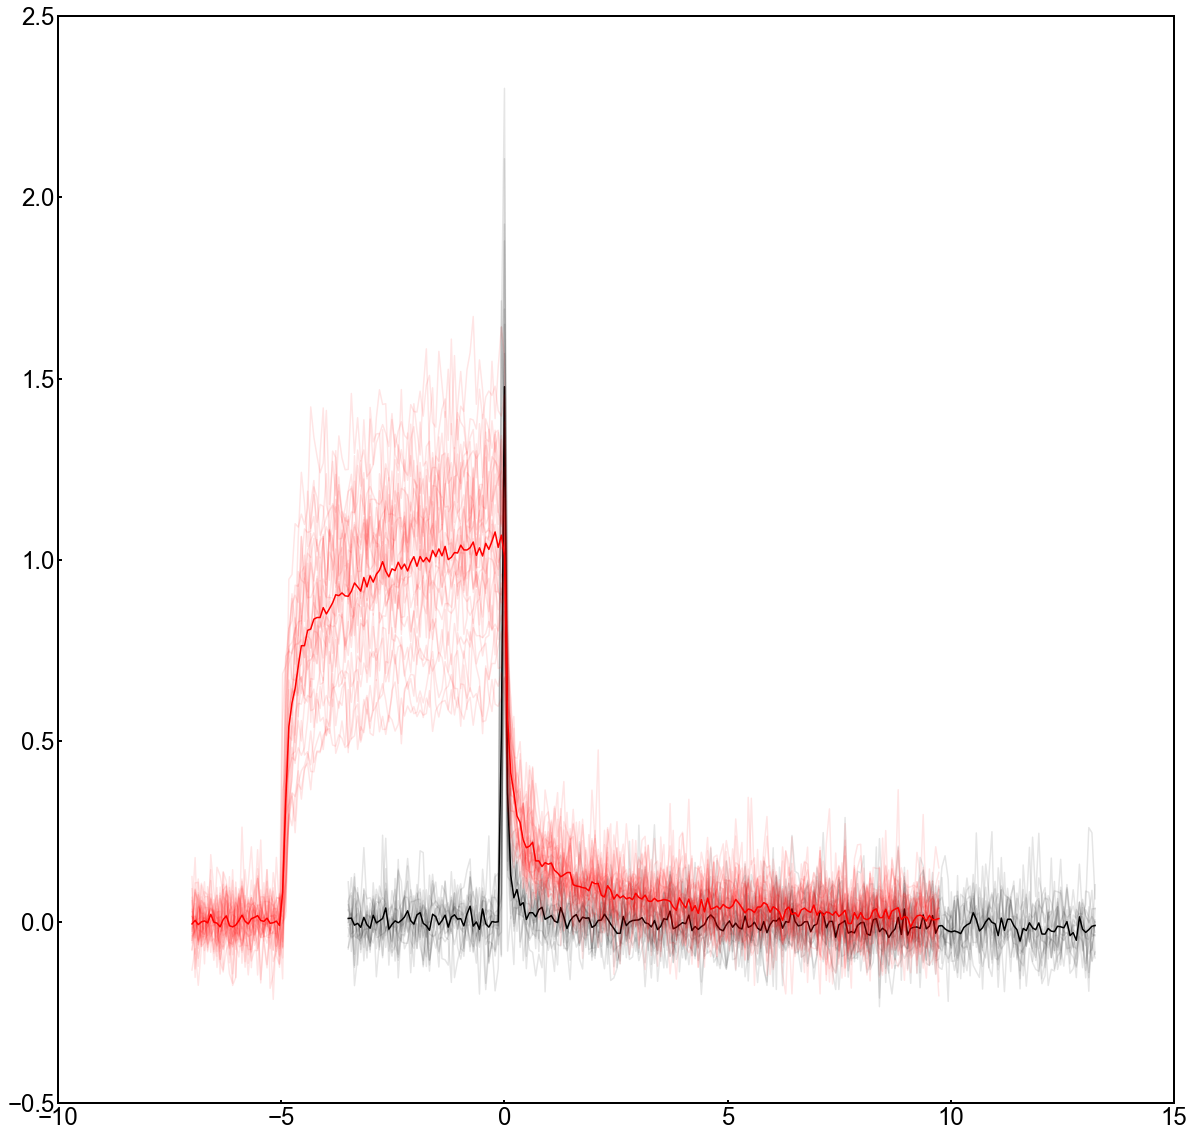

In [38]:
fig = plt.figure(figsize = (20, 20))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
time_normal_100msec = [(i-50)*0.07 for i in range(len(average_normal_100msec))]
time_normal_5sec = [(i-100)*0.07 for i in range(len(average_normal))]
plt.plot(time_normal_100msec, average_normal_100msec, color = 'black')
plt.plot(time_normal_100msec, data_set_100msec - data_set_100msec.iloc[:10, :].mean(), color = 'black', alpha = 0.1)
plt.plot(time_normal_5sec, average_normal, color = 'red')
plt.plot(time_normal_5sec, data_set_5sec - data_set_5sec.iloc[:10, :].mean(), color = 'red', alpha = 0.1)
plt.ylim(-0.5, 2.5)
plt.xlim(-10, 15)
plt.show()

#pdfのセーブ
pp = PdfPages('./Fig3c_outline.pdf')
pp.savefig(fig)
pp.close()

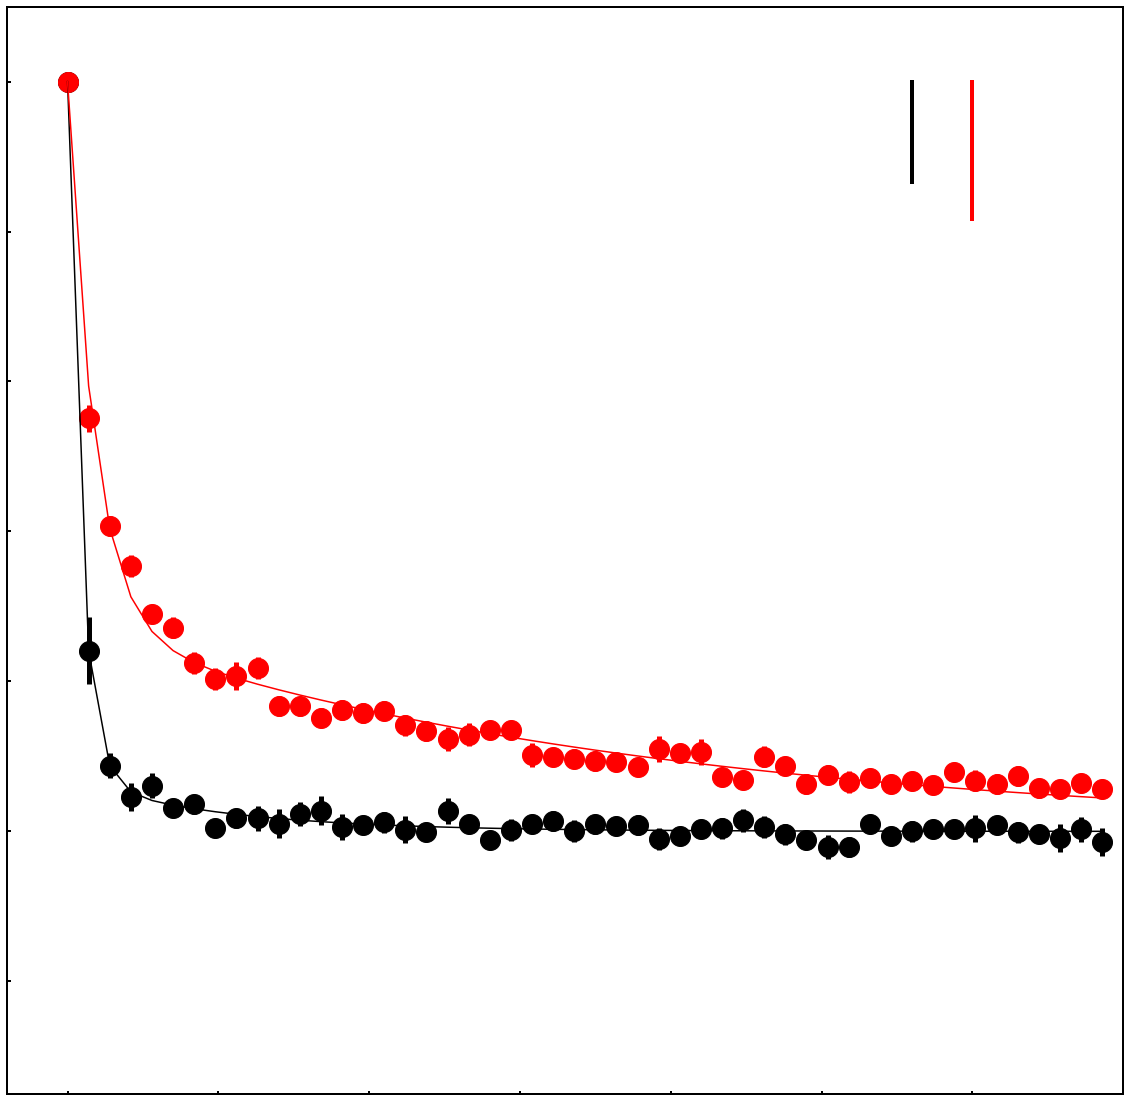

In [39]:
#実測データのプロット
fig = plt.figure(figsize = (20, 20))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
time_normal_100msec = [(i)*0.07 for i in range(len(average_normal_100msec[50:100]))]
time_normal_5sec = [(i)*0.07 for i in range(len(average_normal[100:150]))]


#SEMの計算
data_set_100msec = data_set_100msec - np.mean(data_set_100msec.iloc[:10, :])
data_set_100msec = data_set_100msec/data_set_100msec.iloc[50, :]*100
sem_100msec = data_set_100msec.sem(axis = 1)
sem_100msec[50] = 0

data_set_5sec = data_set_5sec - np.mean(data_set_5sec.iloc[:10, :])
data_set_5sec = data_set_5sec/data_set_5sec.iloc[100, :]*100
sem_5sec = data_set_5sec.sem(axis = 1)
sem_5sec[100] = 0


#1˚Cを示すバーを挿入
normal_100msec_bar = [100 - 20/max(average_normal_100msec)*i/100 for i in range(100)]
normal_100msec_bar_pos = [2.8 for i in range(len(normal_100msec_bar))]
plt.plot(normal_100msec_bar_pos, normal_100msec_bar, linewidth = 4, color = 'black', linestyle = '-')

#1˚Cを示すバーを挿入
normal_bar = [100 - 20/max(average_normal)*i/100 for i in range(100)]
normal_bar_pos = [3.0 for i in range(len(normal_bar))]
plt.plot(normal_bar_pos, normal_bar, linewidth = 4, color = 'red', linestyle = '-')


average_normal_100msec = average_normal_100msec/average_normal_100msec[50]
average_normal = average_normal/average_normal[100]

plt.errorbar(time_normal_100msec, average_normal_100msec[50:100]*100/average_normal_100msec[50], yerr = np.ravel(sem_100msec)[50:100], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='black')
plt.errorbar(time_normal_5sec, average_normal[100:150]*100/average_normal[100], yerr = np.ravel(sem_5sec)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='red')
plt.plot(time_normal_100msec, average_normal_100msec[50:100]*100/average_normal_100msec[50], color = 'black', markersize = 20, marker = 'o', linewidth = 0)
plt.plot(time_normal_5sec, average_normal[100:150]*100/average_normal[100], color = 'red', markersize = 20, marker = 'o', linewidth = 0)
#plt.ylim(-20, 120)
#plt.xlabel('Time (sec)', fontsize = 24)
#plt.ylabel('Temperature change rate \n(%, 100% at 0sec)', fontsize = 24)
plt.tick_params(labelbottom=False,
                labelleft=False,
                labelright=False,
                labeltop=False)



#温度緩和の時定数の計算
def relaxation(time, ratio, t1, t2):
    return ratio*np.exp(-time/t1) + (1-ratio)*np.exp(-time/t2)
result_100msec = curve_fit(relaxation, time_normal_100msec, average_normal_100msec[50:100])[0]
result_5sec = curve_fit(relaxation, time_normal_5sec, average_normal[100:150])[0]



plt.xlim(-0.2, 3.5)
plt.ylim(-35, 110)

#fitting結果の図示
plt.plot(time_normal_100msec, relaxation(np.ravel(time_normal_100msec), result_100msec[0], result_100msec[1], result_100msec[2])*100, color = 'black')
plt.plot(time_normal_5sec, relaxation(np.ravel(time_normal_5sec), result_5sec[0], result_5sec[1], result_5sec[2])*100, color = 'red')


#pdfのセーブ
pp = PdfPages('./Fig3c_ralaxation.pdf')
pp.savefig(fig)
pp.close()

In [40]:
#welchのt検定
sum_5sec = data_set_5sec.iloc[102:150].sum().values
sum_100msec = data_set_100msec.iloc[52:100].sum().values
stats.ttest_ind(sum_5sec, sum_100msec, equal_var = False)

Ttest_indResult(statistic=16.456721442435526, pvalue=1.13142310550355e-19)

In [41]:
sem_5sec_bar = (sum_5sec*0.07).std(ddof = 1)/np.sqrt(len(sum_5sec))
sem_100msec_bar = (sum_100msec*0.07).std(ddof = 1)/np.sqrt(len(sum_100msec))

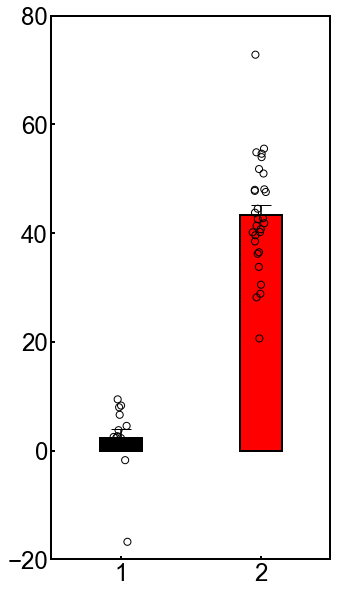

In [42]:
fig = plt.figure(figsize = (5, 10))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
sum_5sec_ave = np.average(sum_5sec*0.07)
sum_100msec_ave = np.average(sum_100msec*0.07)

plt.bar(2, sum_5sec_ave, yerr = [[0], [sem_5sec_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(1, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(2, 0.03, size=len(sum_5sec)) 
plt.scatter(x, sum_5sec*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)
plt.bar(1, sum_100msec_ave, yerr = [[0], [sem_100msec_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(0, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(1, 0.03, size=len(sum_100msec)) 
plt.scatter(x, sum_100msec*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)


plt.ylim(-20, 80)
plt.xlim(0.5, 2.5)

#pdfのセーブ
pp = PdfPages('./Fig3c_ralaxation_bar.pdf')
pp.savefig(fig)
pp.close()

In [43]:
(data_set_100msec - data_set_100msec.iloc[:10, :].mean()).to_csv('100msec_all.csv')
pd.DataFrame(average_normal_100msec).to_csv('100msec_ave.csv')

In [44]:
(data_set_5sec - data_set_5sec.iloc[:10, :].mean()).to_csv('5sec_all.csv')
pd.DataFrame(average_normal).to_csv('5sec_ave.csv')

In [45]:
pd.DataFrame(sum_5sec*0.07).to_csv('AUC_5sec_all.csv')
pd.DataFrame(sum_100msec*0.07).to_csv('AUC_100msec_all.csv')

In [46]:
print(sum_5sec_ave)
print(sem_5sec_bar)
print(sum_100msec_ave)
print(sem_100msec_bar)

43.32829
1.9171741679965841
2.3858073
1.5855694108755485


In [47]:
pd.DataFrame(average_normal[100:150]*100/average_normal[100]).to_csv('5sec_normalized.csv')
pd.DataFrame(average_normal_100msec[50:100]*100/average_normal_100msec[50]).to_csv('100msec_normalized.csv')

In [48]:
pd.DataFrame(sem_5sec[100:150]).to_csv('sem_5sec.csv')
pd.DataFrame(sem_100msec[50:100]).to_csv('sem_100msec.csv')